In [1]:
import os, sys
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import time
import shutil
import collections
from pathlib import Path

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir, verifyFile, verifyType

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/home/vdela/UrbaNet-main/data/', '/home/vdela/UrbaNet-main/models/')

In [6]:
QSCORE_PATH=f"{cfg.DATA_PATH}pp2/{cfg.SCORING_METHOD}/{cfg.PLACE_LEVEL}/"
IMAGES_PATH = f"{cfg.DATA_PATH}pp2/images/"
MODEL_PATH = f"{cfg.MODEL_PATH}pp2/cnn/{cfg.SCORING_METHOD}/{cfg.PLACE_LEVEL}/"
EXPLAIN_PATH = f"{cfg.MODEL_PATH}pp2/explanations/"

In [ ]:
QSCORE_PATH, IMAGES_PATH, MODEL_PATH, EXPLAIN_PATH

In [ ]:
cfg.SCORING_METHOD, cfg.PLACE_LEVEL, cfg.MODEL_PATH

In [7]:
verifyDir(MODEL_PATH)
verifyDir(EXPLAIN_PATH)

In [8]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_type = torch.float32 if device.type == "cuda" else torch.float16
device, torch_type

(device(type='cuda'), torch.float32)

In [9]:
NUM_CLASSES = 1 if "reg" in cfg.ML_TASK else 2

In [ ]:
# def calculate_sim(cam_matrix, et_matrix):
#     """
#     Calcula la Métrica de Similitud (Intersección de Histogramas).
#     Ambas matrices deben ser numpy arrays del mismo tamaño.
#     """
#     # 1. Normalizar ambas matrices para que sumen 1 (Distribuciones de probabilidad)
#     cam_norm = cam_matrix / (np.sum(cam_matrix) + 1e-8)
#     et_norm = et_matrix / (np.sum(et_matrix) + 1e-8)
    
#     # 2. Calcular la intersección mínima por píxel y sumar
#     sim_score = np.sum(np.minimum(cam_norm, et_norm))
#     return sim_score

# def calculate_iou(cam_matrix, et_matrix, threshold_cam=0.15, threshold_et=0.5):
#     """
#     Calcula el Intersection over Union (IoU) a nivel de píxel.
#     Grad-CAM usa 0.15 por defecto (paper original).
#     Eye-Tracking puede usar 0.5 (solo las zonas de mayor fijación).
#     """
#     # 1. Binarizar (Convertir a True/False)
#     cam_mask = cam_matrix >= threshold_cam
#     et_mask  = et_matrix >= threshold_et
    
#     # 2. Calcular Intersección y Unión
#     intersection = np.logical_and(cam_mask, et_mask).sum()
#     union = np.logical_or(cam_mask, et_mask).sum()
    
#     if union == 0:
#         return 0.0
#     return float(intersection / union)

In [10]:
%%time
data_df = pd.read_csv(f"{QSCORE_PATH}scores.csv", sep=";", low_memory=False)
data_df["image_path"] = f"{IMAGES_PATH}" + data_df["image_path"]
data_df["image_id"] = data_df["image_id"].apply(str)
data_df.sort_values(by=[cfg.PERCEPTION_METRIC], ascending=False, inplace=True)
data_df

CPU times: user 194 ms, sys: 80.5 ms, total: 275 ms
Wall time: 311 ms


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,boring,depressing,image_path
98091,51414746fdc9f04926006a00,44.961377,-93.271491,Minneapolis,USA,North America,8.780423,7.500000,7.777778,6.278770,5.000000,3.333333,/home/vdela/UrbaNet-main/data/pp2/images/Minne...
42815,513d677cfdc9f035870040af,42.370774,-71.126977,Boston,USA,North America,8.583389,5.333333,6.055556,5.029020,3.333333,9.166667,/home/vdela/UrbaNet-main/data/pp2/images/Bosto...
50565,513d7c38fdc9f03587006e0f,33.805683,-84.293833,Atlanta,USA,North America,8.505291,6.342593,8.452381,2.291667,0.000000,3.333333,/home/vdela/UrbaNet-main/data/pp2/images/Atlan...
16840,50f5642cfdc9f065f00060f0,47.583294,-122.287884,Seattle,USA,North America,8.478006,7.166667,7.500000,5.538597,3.333333,2.777778,/home/vdela/UrbaNet-main/data/pp2/images/Seatt...
32864,513cc19efdc9f035870014bd,29.751635,-95.466232,Houston,USA,North America,8.440027,7.592593,6.653439,4.321429,2.708333,1.666667,/home/vdela/UrbaNet-main/data/pp2/images/Houst...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1768,50f42c0bfdc9f065f0001786,52.242431,20.898414,Warsaw,Poland,Europe,0.392157,5.899471,2.833333,4.872958,5.740741,3.333333,/home/vdela/UrbaNet-main/data/pp2/images/Warsa...
67419,513e6bb5fdc9f0358700c081,35.646141,139.812366,Tokyo,Japan,Asia,0.277778,3.333333,3.333333,4.538332,5.277778,7.438272,/home/vdela/UrbaNet-main/data/pp2/images/Tokyo...
15585,50f562dafdc9f065f0005ae6,1.292158,103.808340,Singapore,Singapore,Asia,0.256410,4.305556,3.333333,6.666667,5.333333,4.444444,/home/vdela/UrbaNet-main/data/pp2/images/Singa...
68591,513e6f20fdc9f0358700c51f,35.743776,139.773877,Tokyo,Japan,Asia,0.196078,5.092593,3.080808,6.603175,3.055556,2.500000,/home/vdela/UrbaNet-main/data/pp2/images/Tokyo...


In [11]:
rio_df = data_df[data_df["city"] == "Rio De Janeiro"].copy()
print(f"Imágenes en Rio de Janeiro: {len(rio_df)}")
rio_df.head(3)


Imágenes en Rio de Janeiro: 3644


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,boring,depressing,image_path
22133,50f5eaecfdc9f065f0007e32,-22.901318,-43.178843,Rio De Janeiro,Brasil,South America,8.074111,7.222222,6.521164,5.259259,2.444444,5.000000,/home/vdela/UrbaNet-main/data/pp2/images/Rio D...
23068,50f5eb4bfdc9f065f00081e0,-22.924839,-43.387912,Rio De Janeiro,Brasil,South America,7.990805,3.015873,3.333333,3.767806,2.500000,2.261905,/home/vdela/UrbaNet-main/data/pp2/images/Rio D...
23210,50f5eb65fdc9f065f000826f,-22.829954,-43.374070,Rio De Janeiro,Brasil,South America,7.920455,3.740079,3.117284,3.333333,2.222222,5.000000,/home/vdela/UrbaNet-main/data/pp2/images/Rio D...


In [12]:
### SOLO LAS IAMGENES ESCOGIDAS EN EL EXPERIMENTO
image_ids = ['50f5ea5bfdc9f065f0007ab6',
 '50f5ea5bfdc9f065f0007ab9',
 '50f5ea5cfdc9f065f0007abf',
 '50f5ea5cfdc9f065f0007ac5',
 '50f5ea5dfdc9f065f0007ada',
 '50f5ea5ffdc9f065f0007b06',
 '50f5ea60fdc9f065f0007b19',
 '50f5ea61fdc9f065f0007b1d',
 '50f5ea61fdc9f065f0007b1f',
 '50f5ea61fdc9f065f0007b22',
 '50f5ea61fdc9f065f0007b27',
 '50f5eaa5fdc9f065f0007b7b',
 '50f5eaa5fdc9f065f0007b7c',
 '50f5eaa5fdc9f065f0007b81',
 '50f5eaa6fdc9f065f0007b8f',
 '50f5eaa6fdc9f065f0007b94',
 '50f5eaa7fdc9f065f0007ba0',
 '50f5eaa7fdc9f065f0007ba4',
 '50f5eaa9fdc9f065f0007bc7',
 '50f5eac6fdc9f065f0007ca1',
 '50f5eac6fdc9f065f0007cab',
 '50f5eac7fdc9f065f0007cb2',
 '50f5eacafdc9f065f0007cfd',
 '50f5eacbfdc9f065f0007d01',
 '50f5ead3fdc9f065f0007d9f',
 '50f5ead3fdc9f065f0007da4',
 '50f5ead3fdc9f065f0007da9',
 '50f5ead4fdc9f065f0007daa',
 '50f5ead4fdc9f065f0007db2',
 '50f5ead5fdc9f065f0007dbe',
 '50f5ead5fdc9f065f0007dbf',
 '50f5ead5fdc9f065f0007dc2',
 '50f5ead5fdc9f065f0007dc7',
 '50f5ead5fdc9f065f0007dca',
 '50f5ead5fdc9f065f0007dcb',
 '50f5ead6fdc9f065f0007dcd',
 '50f5ead6fdc9f065f0007dcf',
 '50f5ead6fdc9f065f0007dd8',
 '50f5eae9fdc9f065f0007dea',
 '50f5eaeafdc9f065f0007e08',
 '50f5eaecfdc9f065f0007e2c',
 '50f5eaecfdc9f065f0007e2d',
 '50f5eaecfdc9f065f0007e2f',
 '50f5eaecfdc9f065f0007e30',
 '50f5eaecfdc9f065f0007e36',
 '50f5eaedfdc9f065f0007e40',
 '50f5eaedfdc9f065f0007e46',
 '50f5eaedfdc9f065f0007e4b',
 '50f5eaeefdc9f065f0007e50',
 '50f5eaeefdc9f065f0007e55',
 '50f5eaeefdc9f065f0007e58',
 '50f5eaeefdc9f065f0007e59',
 '50f5eaeefdc9f065f0007e5a',
 '50f5eaeefdc9f065f0007e5e',
 '50f5eaeffdc9f065f0007e5f',
 '50f5eaeffdc9f065f0007e68',
 '50f5eaf0fdc9f065f0007e7e',
 '50f5eaf0fdc9f065f0007e81',
 '50f5eaf0fdc9f065f0007e82',
 '50f5eaf1fdc9f065f0007e84',
 '50f5eaf1fdc9f065f0007e86',
 '50f5eaf1fdc9f065f0007e87',
 '50f5eaf1fdc9f065f0007e88',
 '50f5eaf1fdc9f065f0007e8b',
 '50f5eaf1fdc9f065f0007e8c',
 '50f5eaf1fdc9f065f0007e8f',
 '50f5eaf1fdc9f065f0007e91',
 '50f5eaf2fdc9f065f0007e99',
 '50f5eaf2fdc9f065f0007e9c',
 '50f5eaf2fdc9f065f0007e9d',
 '50f5eaf2fdc9f065f0007ea1',
 '50f5eaf2fdc9f065f0007ea2',
 '50f5eaf2fdc9f065f0007ea6',
 '50f5eaf3fdc9f065f0007eac',
 '50f5eaf3fdc9f065f0007eae',
 '50f5eaf3fdc9f065f0007eb6',
 '50f5eaf3fdc9f065f0007eb8',
 '50f5eaf3fdc9f065f0007ebe',
 '50f5eaf3fdc9f065f0007ec1',
 '50f5eaf4fdc9f065f0007ec5',
 '50f5eaf4fdc9f065f0007ec6',
 '50f5eaf4fdc9f065f0007ecd',
 '50f5eaf4fdc9f065f0007ed1',
 '50f5eaf4fdc9f065f0007ed3',
 '50f5eaf4fdc9f065f0007ed4',
 '50f5eaf6fdc9f065f0007efd',
 '50f5eaf9fdc9f065f0007f25',
 '50f5eb16fdc9f065f0007f48',
 '50f5eb23fdc9f065f000802e',
 '50f5eb25fdc9f065f0008060',
 '50f5eb26fdc9f065f0008074',
 '50f5eb27fdc9f065f0008083',
 '50f5eb43fdc9f065f0008140',
 '50f5eb5ffdc9f065f00081fe',
 '50f5eb5ffdc9f065f0008200',
 '50f5eb5ffdc9f065f0008203',
 '50f5eb60fdc9f065f000820c',
 '50f5eb60fdc9f065f0008211',
 '50f5eb60fdc9f065f0008216',
 '50f5eb60fdc9f065f0008219',
 '50f5eb61fdc9f065f0008224',
 '50f5eb61fdc9f065f000822b',
 '50f5eb62fdc9f065f0008237',
 '50f5eb62fdc9f065f0008244',
 '50f5eb63fdc9f065f0008245',
 '50f5eb63fdc9f065f0008248',
 '50f5eb63fdc9f065f000824f',
 '50f5eb63fdc9f065f0008253',
 '50f5eb63fdc9f065f0008258',
 '50f5eb64fdc9f065f0008265',
 '50f5eb64fdc9f065f0008267',
 '50f5eb64fdc9f065f0008268',
 '50f5eb64fdc9f065f000826c',
 '50f5eb64fdc9f065f000826d',
 '50f5eb65fdc9f065f0008273',
 '50f5eb66fdc9f065f0008286',
 '50f5eb66fdc9f065f000828d',
 '50f5eb66fdc9f065f000828e',
 '50f5eb67fdc9f065f0008294',
 '50f5eb67fdc9f065f0008298',
 '50f5eb67fdc9f065f000829f',
 '50f5eb68fdc9f065f00082a3',
 '50f5eb68fdc9f065f00082a7',
 '50f5eb68fdc9f065f00082ae',
 '50f5eb68fdc9f065f00082b0',
 '50f5eb69fdc9f065f00082bb',
 '50f5eb69fdc9f065f00082bc',
 '50f5eb69fdc9f065f00082c0',
 '50f5eb69fdc9f065f00082c9',
 '50f5eb69fdc9f065f00082cc',
 '50f5eb69fdc9f065f00082cd',
 '50f5eb6afdc9f065f00082d4',
 '50f5eb6afdc9f065f00082d5',
 '50f5eb6afdc9f065f00082d9',
 '50f5eb6afdc9f065f00082df',
 '50f5eb6afdc9f065f00082e1',
 '50f5eb6afdc9f065f00082e2',
 '50f5ebc6fdc9f065f00084ea',
 '50f5ebcafdc9f065f0008548',
 '50f5ebcbfdc9f065f000855e',
 '50f5ebd2fdc9f065f00085e6',
 '50f5ebd2fdc9f065f00085ed',
 '50f5ebd2fdc9f065f00085f0',
 '50f5ec0dfdc9f065f0008647',
 '50f5ec0efdc9f065f0008658',
 '50f5ec17fdc9f065f0008708',
 '50f5ec18fdc9f065f0008719',
 '50f5ec1ffdc9f065f00087a4',
 '50f5ec37fdc9f065f0008802',
 '50f5ec40fdc9f065f00088bc']

In [13]:
len(image_ids)

150

In [14]:
# Suponiendo que tu array de IDs ya está definido como image_ids
# Si no está definido, puedes copiar y pegar la definición de tu array

# Crea una lista de números del 1 al 150 (o el número de IDs que tengas)
contador = list(range(0, len(image_ids) ))

# Crea un DataFrame con las dos columnas
df = pd.DataFrame({
    'Contador': contador,
    'ID': image_ids
})


In [ ]:
df.shape

In [ ]:
df[ (df["Contador"] == 56 ) | (df["Contador"] == 117 ) ]

In [15]:
import shutil
import os
import pandas as pd

# Define las rutas

origen_dir = "/home/vdela/UrbaNet-main/data/pp2/images/Rio De Janeiro"
destino_dir = "/home/vdela/UrbaNet-main/data/pp2/Rio"
# Asegúrate de que la carpeta de destino exista
os.makedirs(destino_dir, exist_ok=True)


# Iterar y copiar
for _, row in df.iterrows():
    contador = row['Contador'] #- 1
    img_id = row['ID']
    
    archivo_origen = f"{img_id}.JPG"
    ruta_origen = os.path.join(origen_dir, archivo_origen)

    archivo_destino = f"{contador}.JPG"
    ruta_destino = os.path.join(destino_dir, archivo_destino)

    if os.path.exists(ruta_origen):
        shutil.copy2(ruta_origen, ruta_destino)
        print(f"Copiado {archivo_origen} → {archivo_destino}")
    else:
        print(f"No se encontró: {archivo_origen}")


Copiado 50f5ea5bfdc9f065f0007ab6.JPG → 0.JPG
Copiado 50f5ea5bfdc9f065f0007ab9.JPG → 1.JPG
Copiado 50f5ea5cfdc9f065f0007abf.JPG → 2.JPG
Copiado 50f5ea5cfdc9f065f0007ac5.JPG → 3.JPG
Copiado 50f5ea5dfdc9f065f0007ada.JPG → 4.JPG
Copiado 50f5ea5ffdc9f065f0007b06.JPG → 5.JPG
Copiado 50f5ea60fdc9f065f0007b19.JPG → 6.JPG
Copiado 50f5ea61fdc9f065f0007b1d.JPG → 7.JPG
Copiado 50f5ea61fdc9f065f0007b1f.JPG → 8.JPG
Copiado 50f5ea61fdc9f065f0007b22.JPG → 9.JPG
Copiado 50f5ea61fdc9f065f0007b27.JPG → 10.JPG
Copiado 50f5eaa5fdc9f065f0007b7b.JPG → 11.JPG
Copiado 50f5eaa5fdc9f065f0007b7c.JPG → 12.JPG
Copiado 50f5eaa5fdc9f065f0007b81.JPG → 13.JPG
Copiado 50f5eaa6fdc9f065f0007b8f.JPG → 14.JPG
Copiado 50f5eaa6fdc9f065f0007b94.JPG → 15.JPG
Copiado 50f5eaa7fdc9f065f0007ba0.JPG → 16.JPG
Copiado 50f5eaa7fdc9f065f0007ba4.JPG → 17.JPG
Copiado 50f5eaa9fdc9f065f0007bc7.JPG → 18.JPG
Copiado 50f5eac6fdc9f065f0007ca1.JPG → 19.JPG
Copiado 50f5eac6fdc9f065f0007cab.JPG → 20.JPG
Copiado 50f5eac7fdc9f065f0007cb2.JPG → 21.JP

In [16]:
from py.models.classification.cnn.vgg import VGG16

model = VGG16(num_classes=2, use_gap=True)
model.load_state_dict(torch.load(f"{MODEL_PATH}{cfg.MODEL_FEATURE_NAME}_best_model_new2.pth"))
model.eval()

VGG16(
  (feature_maps): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

In [17]:
from py.models.explainers import GradCAM
from py.models.datasets.transformations import ImageTransforms
from PIL import Image

RIO_DIR    = f"{cfg.DATA_PATH}pp2/Rio"
GRADCAM_DIR = f"{RIO_DIR}/GradCAM"
COMP_DIR    = f"{RIO_DIR}/Comparations"

os.makedirs(GRADCAM_DIR, exist_ok=True)
os.makedirs(COMP_DIR,    exist_ok=True)

transforms_list = ImageTransforms().get(model_name=cfg.MODEL_FEATURE_NAME)
gradcam = GradCAM(model)

print(f"Directorios creados:")
print(f"  GradCAM     → {GRADCAM_DIR}")
print(f"  Comparisons → {COMP_DIR}")


Directorios creados:
  GradCAM     → /home/vdela/UrbaNet-main/data/pp2/Rio/GradCAM
  Comparisons → /home/vdela/UrbaNet-main/data/pp2/Rio/Comparations


In [18]:
errors = []

for i in tqdm(range(150), desc="GradCAM Rio"):
    img_path    = os.path.join(RIO_DIR, f"{i}.JPG")
    gc_path     = os.path.join(GRADCAM_DIR, f"{i}.JPG")
    comp_path   = os.path.join(COMP_DIR, f"{i}.JPG")

    if not os.path.exists(img_path):
        errors.append({"i": i, "error": "imagen no encontrada"})
        continue

    try:
        original = Image.open(img_path).convert("RGB")

        # --- GradCAM ---
        cam_heatmap, pred_class = gradcam.generate_cam(
            original,
            transforms_list=transforms_list["val"],
            target_class=None
        )
        viz, _ = gradcam.visualize(original, cam_heatmap)

        # Guardar solo el GradCAM
        Image.fromarray(viz).save(gc_path, quality=90)

        # --- Comparación: original | GradCAM ---
        orig_arr = np.array(original)
        w = orig_arr.shape[1]
        h = orig_arr.shape[0]
        viz_resized = np.array(Image.fromarray(viz).resize((w, h)))

        comparison = np.concatenate([orig_arr, viz_resized], axis=1)
        Image.fromarray(comparison).save(comp_path, quality=90)

    except Exception as e:
        errors.append({"i": i, "error": str(e)})

print(f"\nCompletado: {150 - len(errors)}/150 imágenes procesadas")
if errors:
    print(f"Errores ({len(errors)}):")
    for err in errors:
        print(f"  imagen {err['i']}: {err['error']}")


GradCAM Rio: 100%|██████████| 150/150 [00:16<00:00,  9.33it/s]


Completado: 150/150 imágenes procesadas


In [19]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import os
from tqdm import tqdm

RIO_DIR      = f"{cfg.DATA_PATH}pp2/Rio"
GRADCAM_DIR  = f"{RIO_DIR}/GradCAM"
HEATMAP_DIR  = f"{RIO_DIR}/heatmaps"
COMP2_DIR    = f"{RIO_DIR}/Comparations2"

os.makedirs(COMP2_DIR, exist_ok=True)

LABELS      = ["Original", "GradCAM", "EyeTracking"]
LABEL_H     = 40           # altura de la barra de etiquetas en px
BG_COLOR    = (30, 30, 30) # fondo oscuro
TEXT_COLOR  = (255, 255, 255)

# Intentar cargar fuente del sistema; si no, usar la default
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
except:
    font = ImageFont.load_default()

def add_label_bar(panel: Image.Image, label: str) -> Image.Image:
    """Agrega una barra de etiqueta encima de un panel."""
    w, h = panel.size
    bar = Image.new("RGB", (w, LABEL_H), BG_COLOR)
    draw = ImageDraw.Draw(bar)
    bbox = draw.textbbox((0, 0), label, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]
    draw.text(((w - text_w) // 2, (LABEL_H - text_h) // 2), label, fill=TEXT_COLOR, font=font)
    combined = Image.new("RGB", (w, LABEL_H + h))
    combined.paste(bar,   (0, 0))
    combined.paste(panel, (0, LABEL_H))
    return combined

errors = []

for i in tqdm(range(150), desc="Comparations2"):
    orig_path    = os.path.join(RIO_DIR,     f"{i}.JPG")
    gc_path      = os.path.join(GRADCAM_DIR, f"{i}.JPG")
    heatmap_path = os.path.join(HEATMAP_DIR, f"heatmap_{i}.png")
    out_path     = os.path.join(COMP2_DIR,   f"{i}.JPG")

    missing = [p for p in [orig_path, gc_path, heatmap_path] if not os.path.exists(p)]
    if missing:
        errors.append({"i": i, "missing": missing})
        continue

    try:
        orig    = Image.open(orig_path).convert("RGB")
        gc      = Image.open(gc_path).convert("RGB")
        heatmap = Image.open(heatmap_path).convert("RGB")

        w, h = orig.size
        gc      = gc.resize((w, h), Image.LANCZOS)
        heatmap = heatmap.resize((w, h), Image.LANCZOS)

        # Añadir etiqueta a cada panel
        panel_orig    = add_label_bar(orig,    LABELS[0])
        panel_gc      = add_label_bar(gc,      LABELS[1])
        panel_heatmap = add_label_bar(heatmap, LABELS[2])

        # Concatenar horizontalmente
        total_w = w * 3
        total_h = LABEL_H + h
        comparison = Image.new("RGB", (total_w, total_h))
        comparison.paste(panel_orig,    (0,     0))
        comparison.paste(panel_gc,      (w,     0))
        comparison.paste(panel_heatmap, (w * 2, 0))

        comparison.save(out_path, quality=90)

    except Exception as e:
        errors.append({"i": i, "error": str(e)})

print(f"\nCompletado: {150 - len(errors)}/150 imágenes procesadas")
print(f"Guardado en: {COMP2_DIR}")
if errors:
    print(f"\nErrores ({len(errors)}):")
    for err in errors:
        print(f"  imagen {err['i']}: {err}")

Comparations2: 100%|██████████| 150/150 [00:01<00:00, 104.69it/s]


Completado: 150/150 imágenes procesadas
Guardado en: /home/vdela/UrbaNet-main/data/pp2/Rio/Comparations2


In [20]:
import numpy as np
import os

def export_gradcam_to_npz(cam_matrix, image_id, output_dir):
    """
    Exporta la matriz Grad-CAM a .npz guardando el mapa continuo normalizado.
    La binarización bruta es > 0, pero el umbral real (0.15) se aplicará
    dinámicamente durante el cálculo de las métricas.
    """
    # 1. Asegurar que esté en float y normalizar de 0.0 a 1.0
    cam_continuo = cam_matrix.astype(np.float64)
    max_val = cam_continuo.max()
    if max_val > 0:
        cam_continuo /= max_val
        
    # 2. Binarización bruta (solo separa activaciones reales del cero absoluto)
    cam_binario = (cam_continuo > 0).astype(bool) 
    
    # 3. Guardar el archivo
    ruta_salida = os.path.join(output_dir, f"mapas_gradcam_img_{image_id}.npz")
    np.savez_compressed(
        ruta_salida,
        continuo=cam_continuo,
        binario=cam_binario
    )

In [ ]:
from PIL import Image
import os
import numpy as np

# 1. DEFINES LA RUTA EXACTA QUE PEDISTE
GRADCAM_NPZ_DIR = f"{cfg.DATA_PATH}pp2/Rio/export_gradcam_to_npz"
os.makedirs(GRADCAM_NPZ_DIR, exist_ok=True)

errors = []

for i in tqdm(range(150), desc="GradCAM Rio"):
    img_path    = os.path.join(RIO_DIR, f"{i}.JPG")
    gc_path     = os.path.join(GRADCAM_DIR, f"{i}.JPG")

    if not os.path.exists(img_path):
        continue

    try:
        original = Image.open(img_path).convert("RGB")

        # Generar GradCAM
        cam_heatmap, pred_class = gradcam.generate_cam(
            original,
            transforms_list=transforms_list["val"],
            target_class=None
        )
        
        # Extraer visualización y matriz
        viz, cam_resized = gradcam.visualize(original, cam_heatmap)

        # Guardar la foto del GradCAM
        Image.fromarray(viz).save(gc_path, quality=90)
        
        # 2. LLAMAS A LA FUNCIÓN PASÁNDOLE TU NUEVA RUTA
        export_gradcam_to_npz(
            cam_matrix=cam_resized, 
            image_id=i, 
            output_dir=GRADCAM_NPZ_DIR,  # <--- Aquí le inyectas la carpeta destino
            threshold=0.20 
        )

    except Exception as e:
        errors.append({"i": i, "error": str(e)})

print(f"\n¡Proceso finalizado!")
print(f"Los archivos .npz se guardaron en: {GRADCAM_NPZ_DIR}")

GradCAM Rio: 100%|██████████| 150/150 [00:16<00:00,  8.99it/s]


¡Proceso finalizado!
Los archivos .npz se guardaron en: /home/vdela/UrbaNet-main/data/pp2/Rio/export_gradcam_to_npz


In [38]:
import numpy as np

# 1. Cargar un archivo .npz de prueba (cambia la ruta a uno tuyo real)
#uta_archivo = 'mapas_gradcam_img_0.npz'
ruta_archivo = '/home/vdela/UrbaNet-main/data/pp2/Rio/matriz_npz/mapas_hololens_img_0.npz'
data = np.load(ruta_archivo)

# 2. Ver qué "llaves" o matrices están guardadas dentro
print(f"Llaves guardadas en el archivo: {data.files}\n")

# 3. Extraer la matriz continua para analizarla
mapa_continuo = data['continuo']
mapa_binario = data['binario']

# 4. Ver el TAMAÑO (Dimensiones)
print("--- ANÁLISIS DE TAMAÑO (SHAPE) ---")
print(f"Resolución del mapa continuo: {mapa_continuo.shape}")
print(f"Resolución del mapa binario:  {mapa_binario.shape}\n")

# 5. Ver el RANGO (Mínimos y Máximos)
print("--- ANÁLISIS DE RANGO (MIN/MAX) ---")
print(f"Mapa Continuo -> Mínimo: {mapa_continuo.min():.4f} | Máximo: {mapa_continuo.max():.4f}")
print(f"Mapa Binario  -> Mínimo: {mapa_binario.min()} | Máximo: {mapa_binario.max()}")

Llaves guardadas en el archivo: ['binario', 'continuo']

--- ANÁLISIS DE TAMAÑO (SHAPE) ---
Resolución del mapa continuo: (600, 800)
Resolución del mapa binario:  (600, 800)

--- ANÁLISIS DE RANGO (MIN/MAX) ---
Mapa Continuo -> Mínimo: 0.0000 | Máximo: 1.0000
Mapa Binario  -> Mínimo: 0.0 | Máximo: 1.0


In [ ]:
### METRICAS /home/vdela/UrbaNet-main/notebooks/Explanations/GradCAM.ipynb

In [22]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
# Cambia estas rutas por las tuyas reales
# DIR_GRADCAM = "data/pp2/Rio/export_gradcam_to_npz"
# DIR_HOLOLENS = "data/pp2/Rio/matriz_npz" 
DIR_GRADCAM = "/home/vdela/UrbaNet-main/data/pp2/Rio/export_gradcam_to_npz"
DIR_HOLOLENS = "/home/vdela/UrbaNet-main/data/pp2/Rio/matriz_npz"

In [23]:
# ==========================================
# 2. FUNCIONES MATEMÁTICAS (XAI vs Humano)
# ==========================================
def calc_iou(map_ai_continuo, map_human_continuo, tau_ai=0.2, tau_et=0.2):
    """
    Intersection over Union (IoU).
    Aplica los umbrales topológicos a los mapas continuos antes de evaluar.
    - tau_ai: 0.2 (Supresión de ruido residual Grad-CAM)
    - tau_et: 0.2 (Criterio FWHM para el núcleo foveal del HoloLens)
    """
    # 1. Binarización Dinámica (Decapitación geométrica)
    mask_ai = map_ai_continuo >= tau_ai
    mask_human = map_human_continuo >= tau_et
    
    # 2. Operaciones lógicas booleanas
    intersection = np.logical_and(mask_ai, mask_human).sum()
    union = np.logical_or(mask_ai, mask_human).sum()
    
    return float(intersection / union) if union > 0 else 0.0

def calc_sim(map_ai, map_human):
    """Similarity Metric (SIM) usando los mapas continuos."""
    # Normalizar para que sean distribuciones de probabilidad (sumen 1)
    map_ai_norm = map_ai / (np.sum(map_ai) )
    map_human_norm = map_human / (np.sum(map_human) )
    return float(np.sum(np.minimum(map_ai_norm, map_human_norm)))

def calc_nss(map_ai_continuo, map_human_puntos):
    """
    Normalized Scanpath Saliency (NSS).
    Evalúa el mapa continuo de la IA en los puntos EXACTOS donde miró el humano.
    """
    # 1. Normalizar el mapa de la IA (Z-score: media 0, desv 1)
    mean = np.mean(map_ai_continuo)
    std = np.std(map_ai_continuo)
    if std == 0:
        return 0.0
    
    ai_norm = (map_ai_continuo - mean) / std
    
    # 2. Extraer los valores de la IA solo en los píxeles donde el humano miró (>0)
    # map_human_puntos es tu 'binario' del HoloLens (que guarda los puntos crudos)
    fijaciones = ai_norm[map_human_puntos > 0]
    
    if len(fijaciones) == 0:
        return 0.0
    return float(np.mean(fijaciones))

In [ ]:
DIR_GRADCAM #data/pp2/Rio/export_gradcam_to_npz

In [ ]:
DIR_HOLOLENS

In [25]:
import os

print(f"Directorio actual del Notebook: {os.getcwd()}")

ruta_prueba_gc = os.path.join(DIR_GRADCAM, "mapas_gradcam_img_0.npz")
ruta_prueba_hl = os.path.join(DIR_HOLOLENS, "mapas_hololens_img_0.npz")

print(f"\nBuscando Grad-CAM en: {os.path.abspath(ruta_prueba_gc)}")
print(f"¿Existe el archivo Grad-CAM 0? -> {os.path.exists(ruta_prueba_gc)}")

print(f"\nBuscando HoloLens en: {os.path.abspath(ruta_prueba_hl)}")
print(f"¿Existe el archivo HoloLens 0? -> {os.path.exists(ruta_prueba_hl)}")

#print(f"\nImágenes con error o no encontradas en el bucle anterior: {len(errores)}")

Directorio actual del Notebook: /home/vdela/UrbaNet-main/notebooks/Explanations

Buscando Grad-CAM en: /home/vdela/UrbaNet-main/data/pp2/Rio/export_gradcam_to_npz/mapas_gradcam_img_0.npz
¿Existe el archivo Grad-CAM 0? -> True

Buscando HoloLens en: /home/vdela/UrbaNet-main/data/pp2/Rio/matriz_npz/mapas_hololens_img_0.npz
¿Existe el archivo HoloLens 0? -> True


In [27]:
# ==========================================
# 3. PROCESAMIENTO MASIVO (0 a 149)
# ==========================================
resultados = []
errores = []

# Iteramos sobre las 150 imágenes
for i in tqdm(range(150), desc="Calculando Métricas Cognitivas"):
    ruta_gc = os.path.join(DIR_GRADCAM, f"mapas_gradcam_img_{i}.npz")
    ruta_hl = os.path.join(DIR_HOLOLENS, f"mapas_hololens_img_{i}.npz")
    
    if not os.path.exists(ruta_gc) or not os.path.exists(ruta_hl):
        errores.append(i)
        continue
        
    try:
        # Cargar los diccionarios .npz
        data_gc = np.load(ruta_gc)
        data_hl = np.load(ruta_hl)
        
        # Extraer matrices (Asegurando que sean float para matemáticas)
        gc_cont = data_gc['continuo'].astype(float)
        gc_bin  = data_gc['binario'].astype(bool)
        
        hl_cont = data_hl['continuo'].astype(float)
        hl_bin  = data_hl['binario'].astype(bool) # Este tiene los puntos puros para NSS
        
        # Asegurar mismos tamaños (por si acaso)
        if gc_cont.shape != hl_cont.shape:
            import cv2
            hl_cont = cv2.resize(hl_cont, (gc_cont.shape[1], gc_cont.shape[0]))
            hl_bin = cv2.resize(hl_bin.astype(np.uint8), (gc_cont.shape[1], gc_cont.shape[0])).astype(bool)

        # Calcular Métricas
        #iou_val = calc_iou(gc_bin, hl_bin)
        iou_val = calc_iou(gc_cont, hl_cont, tau_ai=0.2, tau_et=0.2)
        sim_val = calc_sim(gc_cont, hl_cont)
        nss_val = calc_nss(gc_cont, hl_bin)
        
        resultados.append({
            "Image_ID": i,
            "IoU": iou_val,
            "SIM": sim_val,
            "NSS": nss_val
        })
        
    except Exception as e:
        print(f"Error en imagen {i}: {e}")

Calculando Métricas Cognitivas: 100%|██████████| 150/150 [00:03<00:00, 42.74it/s]


In [28]:
data_gc #ojos

NpzFile '/home/vdela/UrbaNet-main/data/pp2/Rio/export_gradcam_to_npz/mapas_gradcam_img_149.npz' with keys: continuo, binario

In [29]:
gc_cont

array([[0.09445959, 0.09445959, 0.09445959, ..., 0.25326907, 0.25326907,
        0.25326907],
       [0.09445959, 0.09445959, 0.09445959, ..., 0.25326907, 0.25326907,
        0.25326907],
       [0.09445959, 0.09445959, 0.09445959, ..., 0.25326907, 0.25326907,
        0.25326907],
       ...,
       [0.        , 0.        , 0.        , ..., 0.07359001, 0.07359001,
        0.07359001],
       [0.        , 0.        , 0.        , ..., 0.07359001, 0.07359001,
        0.07359001],
       [0.        , 0.        , 0.        , ..., 0.07359001, 0.07359001,
        0.07359001]], shape=(300, 400))

In [30]:
resultados

[{'Image_ID': 0,
  'IoU': 0.14964573662350356,
  'SIM': 0.402871637927781,
  'NSS': 0.10042764123477887},
 {'Image_ID': 1,
  'IoU': 0.16909353529044346,
  'SIM': 0.44949744626554494,
  'NSS': 0.6149000512754822},
 {'Image_ID': 2,
  'IoU': 0.1650651195116792,
  'SIM': 0.3498786736492362,
  'NSS': -0.16393038707495217},
 {'Image_ID': 3,
  'IoU': 0.3130088375780782,
  'SIM': 0.5900007222030881,
  'NSS': 1.2348496593524272},
 {'Image_ID': 4,
  'IoU': 0.18040755281361,
  'SIM': 0.4584733836789229,
  'NSS': 0.06230994027227991},
 {'Image_ID': 5,
  'IoU': 0.08341820650856006,
  'SIM': 0.44907741551698177,
  'NSS': 0.06202950293245233},
 {'Image_ID': 6,
  'IoU': 0.23206071757129715,
  'SIM': 0.5519141298043444,
  'NSS': 0.7078873308880048},
 {'Image_ID': 7,
  'IoU': 0.14831884166138,
  'SIM': 0.41966535039965536,
  'NSS': 0.3061713227923478},
 {'Image_ID': 8,
  'IoU': 0.21333355439864707,
  'SIM': 0.4015168119281966,
  'NSS': 0.1611407725169778},
 {'Image_ID': 9,
  'IoU': 0.08623423058760035,


In [31]:
# ==========================================
# 4. GENERACIÓN DE CUADRO PARA PAPER
# ==========================================
# Crear DataFrame con datos crudos
df_resultados = pd.DataFrame(resultados)

# Crear DataFrame Resumen Estilo Paper
resumen_paper = pd.DataFrame({
    'Métrica': ['Intersection over Union (IoU)', 'Similarity Metric (SIM)', 'Normalized Scanpath Saliency (NSS)'],
    'Media ± Desviación': [
        f"{df_resultados['IoU'].mean():.4f} ± {df_resultados['IoU'].std():.4f}",
        f"{df_resultados['SIM'].mean():.4f} ± {df_resultados['SIM'].std():.4f}",
        f"{df_resultados['NSS'].mean():.4f} ± {df_resultados['NSS'].std():.4f}"
    ],
    'Mínimo': [
        f"{df_resultados['IoU'].min():.4f}",
        f"{df_resultados['SIM'].min():.4f}",
        f"{df_resultados['NSS'].min():.4f}"
    ],
    'Máximo': [
        f"{df_resultados['IoU'].max():.4f}",
        f"{df_resultados['SIM'].max():.4f}",
        f"{df_resultados['NSS'].max():.4f}"
    ]
})

print(f"\nProceso finalizado. {len(resultados)} imágenes analizadas con éxito.")
if errores:
    print(f"Archivos faltantes: {len(errores)}")

# Guardamos los crudos para tu historial
df_resultados.to_csv("resultados_metricas_brutas.csv", index=False)

# Mostramos la tabla elegante en el notebook
display(resumen_paper.style.set_caption("Tabla 1: Análisis Cuantitativo de Similitud - Grad-CAM vs Human Eye-Tracking")\
                    .set_properties(**{'text-align': 'center', 'background-color': '#f9f9f9', 'border': '1px solid black'})\
                    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center')]}]))


Proceso finalizado. 150 imágenes analizadas con éxito.


,Métrica,Media ± Desviación,Mínimo,Máximo
0,Intersection over Union (IoU),0.1789 ± 0.1064,0.0000,0.5056
1,Similarity Metric (SIM),0.4080 ± 0.1104,0.1728,0.6740
2,Normalized Scanpath Saliency (NSS),0.2145 ± 0.5371,-1.2904,1.8074


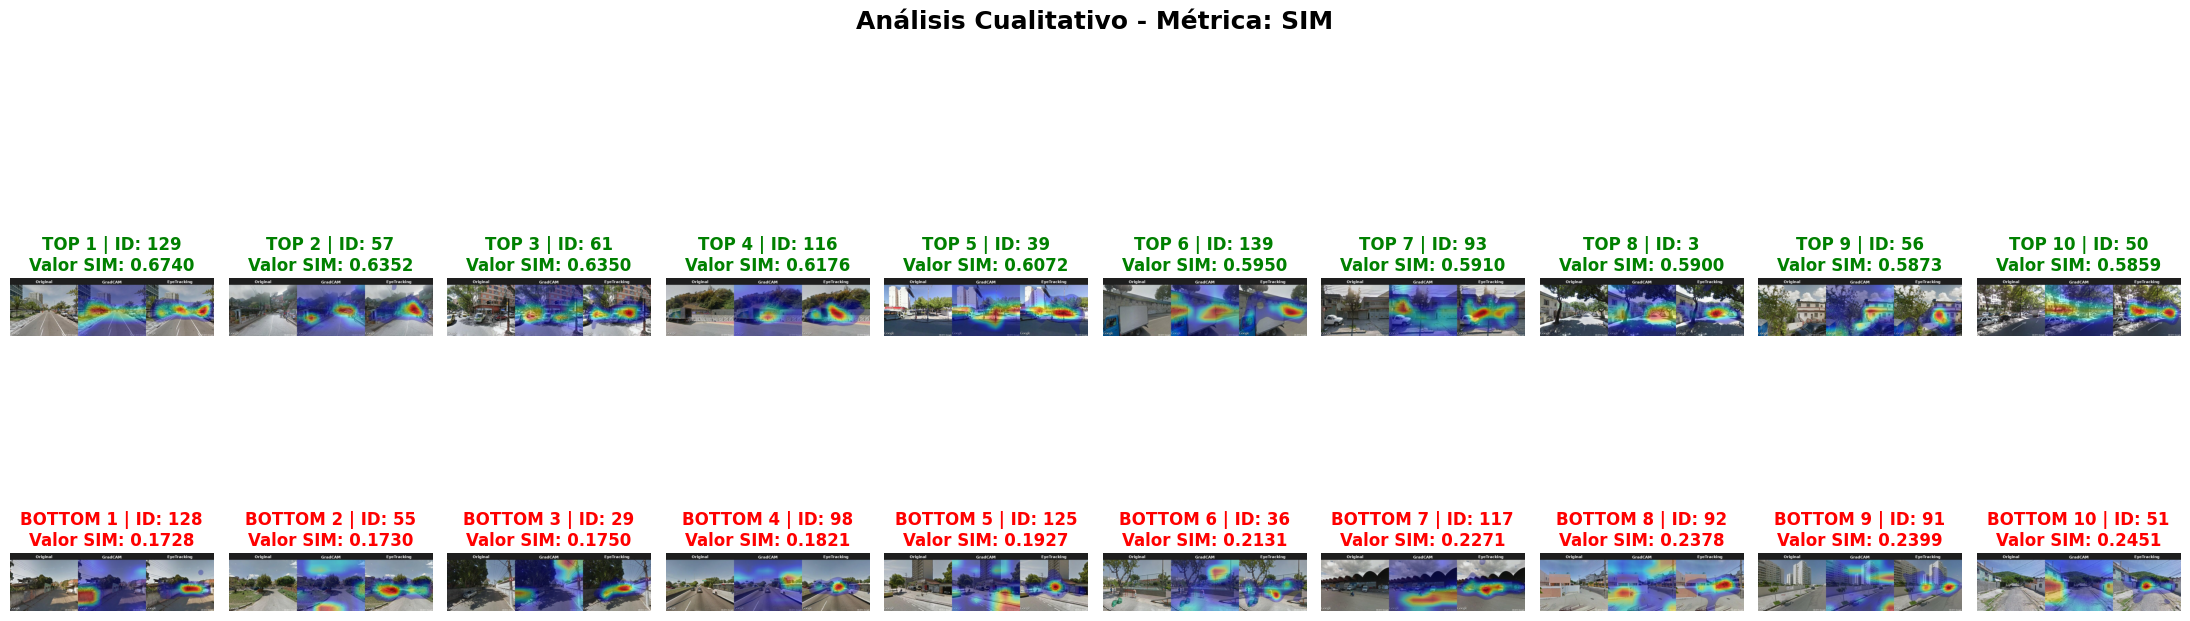

 Gráfico de SIM guardado como top_bottom_SIM.png


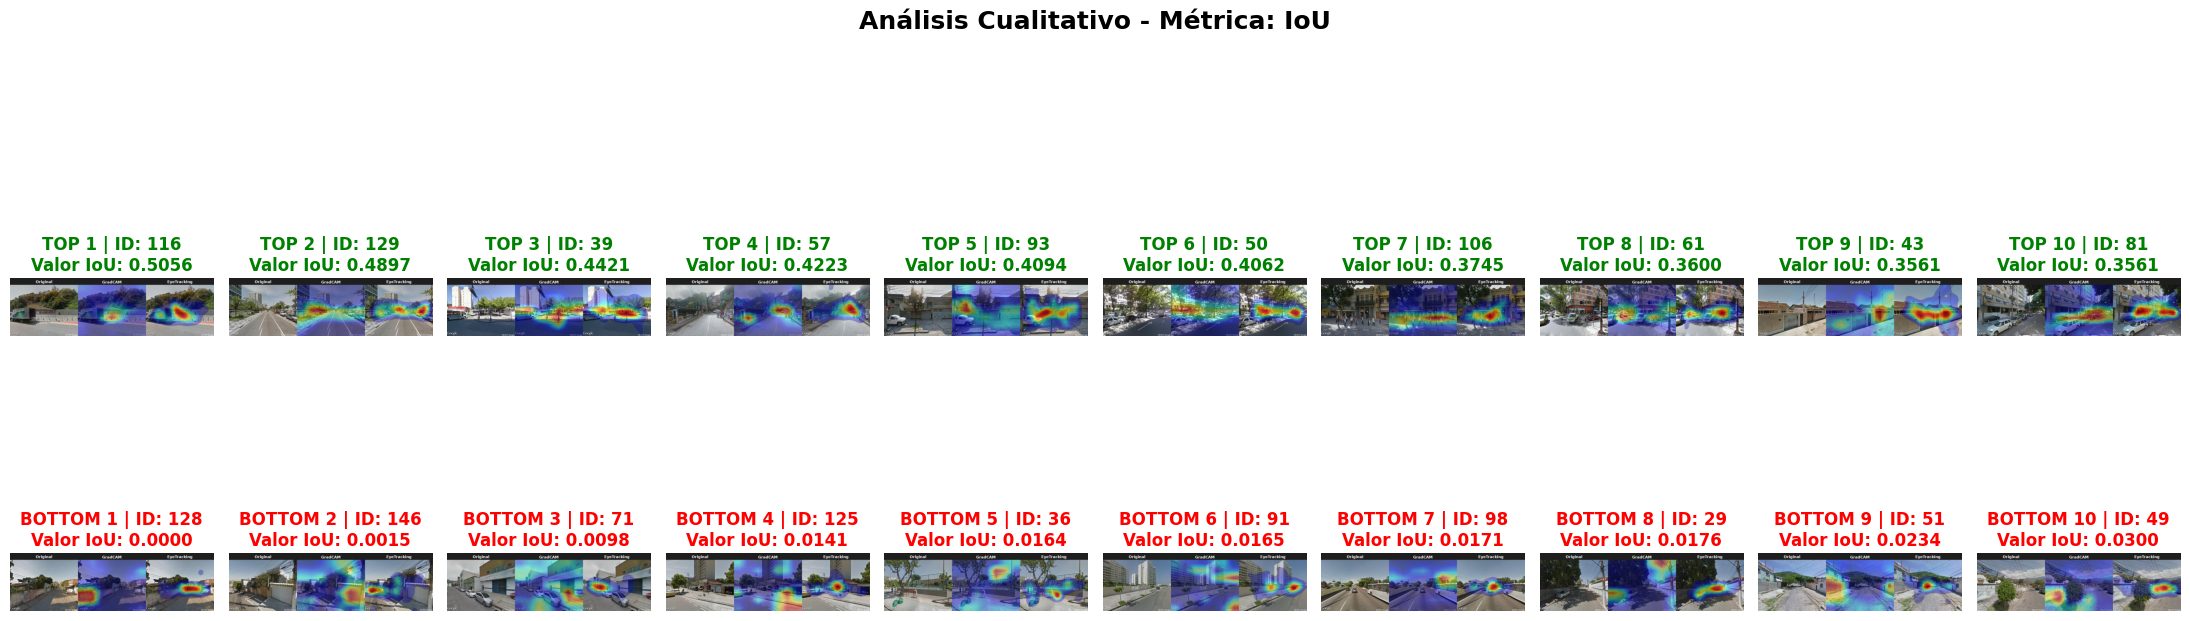

 Gráfico de IoU guardado como top_bottom_IoU.png


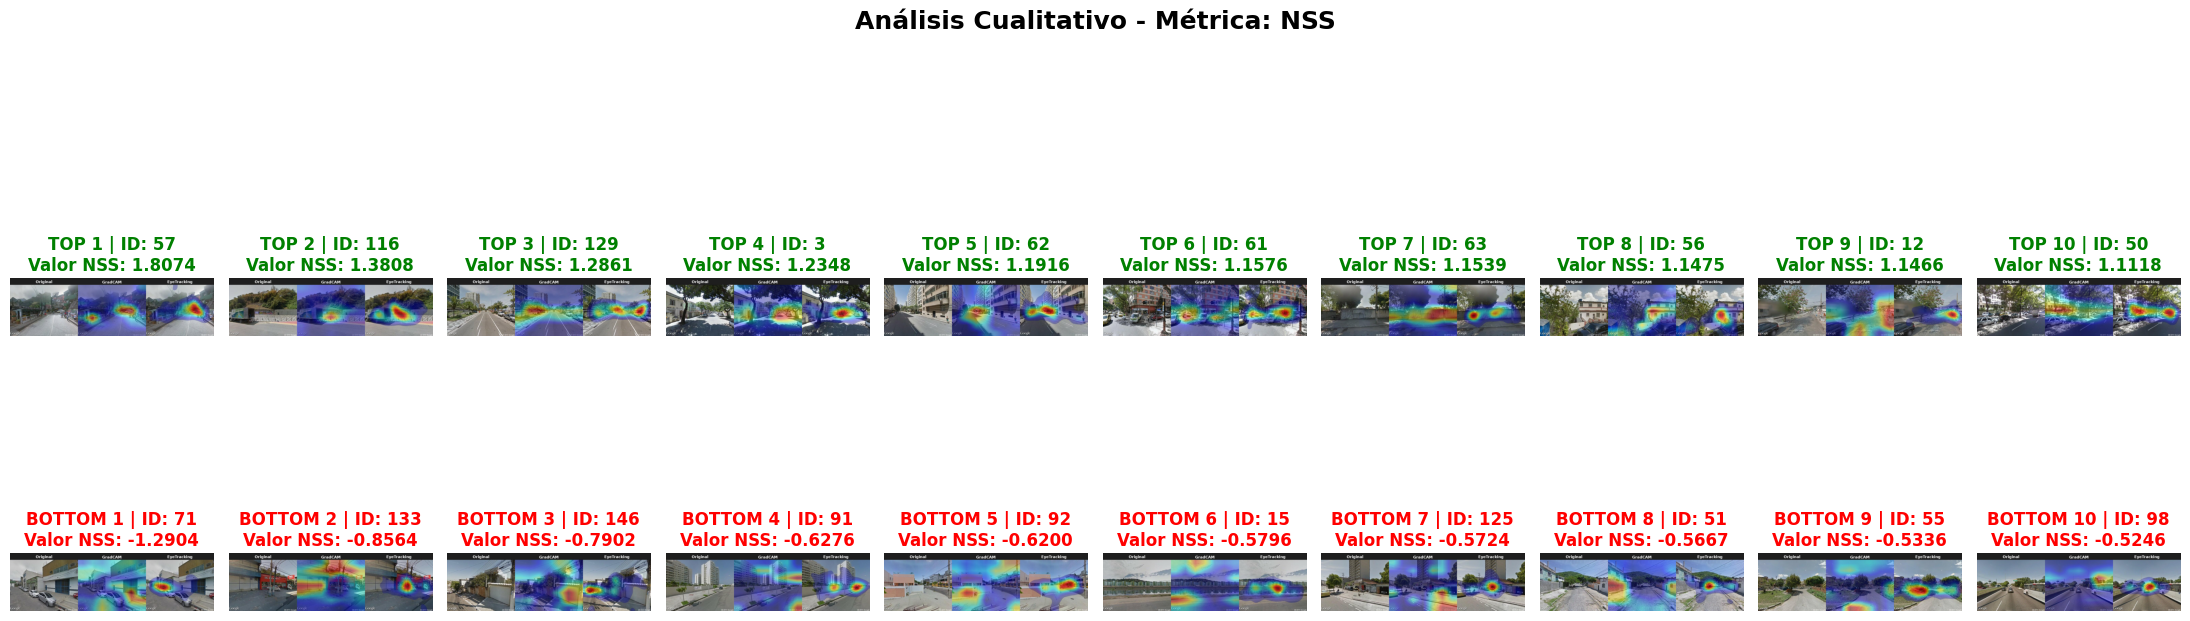

 Gráfico de NSS guardado como top_bottom_NSS.png


In [32]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# ==========================================
# 1. RUTA DE TUS IMÁGENES
# ==========================================
# Si tienes las imágenes de 3 paneles guardadas en la carpeta de Comparaciones, pon esa ruta.
# Si no, puedes usar GRADCAM_DIR o RIO_DIR. Ajusta esta variable a tu estructura:
CARPETA_IMAGENES = f"/home/vdela/UrbaNet-main/data/pp2/Rio/Comparations2" # O la ruta donde esté tu 1.JPG
# /home/vdela/UrbaNet-main/data/pp2/Rio/Comparations2

# ==========================================
# 2. FUNCIÓN DE GRAFICACIÓN PARA PAPER
# ==========================================
def plot_extremos_metrica(df, metrica, img_dir, top_n=10):
    """
    Busca los top_n mejores y peores valores de una métrica y los grafica.
    """
    # Ordenar el DataFrame para obtener los extremos
    mejores = df.nlargest(top_n, metrica)
    peores  = df.nsmallest(top_n, metrica)
    
    # Crear figura: 2 filas (Top y Bottom), 5 columnas
    fig, axes = plt.subplots(2, top_n, figsize=(22, 8))
    fig.suptitle(f'Análisis Cualitativo - Métrica: {metrica}', fontsize=18, fontweight='bold', y=1.02)
    
    # --- FILA 0: LOS MEJORES (TOP 5) ---
    for idx, (index, row) in enumerate(mejores.iterrows()):
        img_id = int(row['Image_ID'])
        val = row[metrica]
        ax = axes[0, idx]
        
        img_path = os.path.join(img_dir, f"{img_id}.JPG")
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f'Img {img_id}\nNo encontrada', ha='center', va='center')
            
        ax.set_title(f'TOP {idx+1} | ID: {img_id}\nValor {metrica}: {val:.4f}', 
                     color='green', fontweight='bold', fontsize=12)
        ax.axis('off')
        
    # --- FILA 1: LOS PEORES (BOTTOM 5) ---
    for idx, (index, row) in enumerate(peores.iterrows()):
        img_id = int(row['Image_ID'])
        val = row[metrica]
        ax = axes[1, idx]
        
        img_path = os.path.join(img_dir, f"{img_id}.JPG")
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f'Img {img_id}\nNo encontrada', ha='center', va='center')
            
        ax.set_title(f'BOTTOM {idx+1} | ID: {img_id}\nValor {metrica}: {val:.4f}', 
                     color='red', fontweight='bold', fontsize=12)
        ax.axis('off')
        
    plt.tight_layout()
    
    # Guardar la figura en alta resolución
    save_path = f"top_bottom_{metrica}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Gráfico de {metrica} guardado como {save_path}")

# ==========================================
# 3. EJECUTAR PARA LAS 3 MÉTRICAS
# ==========================================
# Nota: asegúrate de que df_resultados exista en la memoria de tu notebook
plot_extremos_metrica(df_resultados, 'SIM', CARPETA_IMAGENES, top_n=10)
plot_extremos_metrica(df_resultados, 'IoU', CARPETA_IMAGENES, top_n=10)
plot_extremos_metrica(df_resultados, 'NSS', CARPETA_IMAGENES, top_n=10)

In [33]:
# ==========================================
# 3. PROCESAMIENTO MASIVO (0 a 149)
# ==========================================
resultados = []
errores = []

# Iteramos sobre las 150 imágenes
for i in tqdm(range(150), desc="Calculando Métricas Cognitivas"):
    ruta_gc = os.path.join(DIR_GRADCAM, f"mapas_gradcam_img_{i}.npz")
    ruta_hl = os.path.join(DIR_HOLOLENS, f"mapas_hololens_img_{i}.npz")
    
    if not os.path.exists(ruta_gc) or not os.path.exists(ruta_hl):
        errores.append(i)
        continue
        
    try:
        # Cargar los diccionarios .npz
        data_gc = np.load(ruta_gc)
        data_hl = np.load(ruta_hl)
        
        # Extraer matrices (Asegurando que sean float para matemáticas)
        gc_cont = data_gc['continuo'].astype(float)
        gc_bin  = data_gc['binario'].astype(bool)
        
        hl_cont = data_hl['continuo'].astype(float)
        hl_bin  = data_hl['binario'].astype(bool) # Este tiene los puntos puros para NSS
        
        # Asegurar mismos tamaños (por si acaso)
        if gc_cont.shape != hl_cont.shape:
            import cv2
            hl_cont = cv2.resize(hl_cont, (gc_cont.shape[1], gc_cont.shape[0]))
            hl_bin = cv2.resize(hl_bin.astype(np.uint8), (gc_cont.shape[1], gc_cont.shape[0])).astype(bool)

        # Calcular Métricas
        #iou_val = calc_iou(gc_bin, hl_bin)
        iou_val = calc_iou(gc_cont, hl_cont, tau_ai=0.2, tau_et=0.2)
        sim_val = calc_sim(gc_cont, hl_cont)
        nss_val = calc_nss(gc_cont, hl_bin)
        
        resultados.append({
            "Image_ID": i,
            "IoU": iou_val,
            "SIM": sim_val,
            "NSS": nss_val
        })
        
    except Exception as e:
        print(f"Error en imagen {i}: {e}")

Calculando Métricas Cognitivas: 100%|██████████| 150/150 [00:05<00:00, 26.41it/s]


In [34]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
DIR_GRADCAM = "/home/vdela/UrbaNet-main/data/pp2/Rio/export_gradcam_to_npz"
DIR_HOLOLENS = "/home/vdela/UrbaNet-main/data/pp2/Rio/matriz_npz" 
JSON_PATH = "/home/vdela/UrbaNet-main/data_hololens.json"

# ==========================================
# 2. CARGAR EL JSON DE SCORES
# ==========================================
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    data_hololens = json.load(f)

# ==========================================
# 3. FUNCIONES MATEMÁTICAS (Mantenemos las mismas)
# ==========================================
def calc_iou(map_ai_continuo, map_human_continuo, tau_ai=0.2, tau_et=0.2):
    """
    Intersection over Union (IoU).
    Aplica los umbrales topológicos a los mapas continuos antes de evaluar.
    - tau_ai: 0.2 (Supresión de ruido residual Grad-CAM)
    - tau_et: 0.2 (Criterio FWHM para el núcleo foveal del HoloLens)
    """
    # 1. Binarización Dinámica (Decapitación geométrica)
    mask_ai = map_ai_continuo >= tau_ai
    mask_human = map_human_continuo >= tau_et
    
    # 2. Operaciones lógicas booleanas
    intersection = np.logical_and(mask_ai, mask_human).sum()
    union = np.logical_or(mask_ai, mask_human).sum()
    
    return float(intersection / union) if union > 0 else 0.0

def calc_sim(map_ai, map_human):
    map_ai_norm = map_ai / (np.sum(map_ai))
    map_human_norm = map_human / (np.sum(map_human))
    return float(np.sum(np.minimum(map_ai_norm, map_human_norm)))

def calc_nss(map_ai_continuo, map_human_puntos):
    mean = np.mean(map_ai_continuo)
    std = np.std(map_ai_continuo)
    if std == 0: return 0.0
    ai_norm = (map_ai_continuo - mean) / std
    fijaciones = ai_norm[map_human_puntos > 0]
    if len(fijaciones) == 0: return 0.0
    return float(np.mean(fijaciones))

# ==========================================
# 4. PROCESAMIENTO MASIVO CRUZADO
# ==========================================
resultados = []
errores = []

# Iteramos sobre las 150 imágenes
for i in tqdm(range(150), desc="Generando CSV de Métricas y Scores"):
    ruta_gc = os.path.join(DIR_GRADCAM, f"mapas_gradcam_img_{i}.npz")
    ruta_hl = os.path.join(DIR_HOLOLENS, f"mapas_hololens_img_{i}.npz")
    
    # Extraer los scores del JSON (el JSON usa el índice 'i' como string, ej. "0")
    str_i = str(i)
    avg_hl = None
    avg_pp2 = None
    
    if str_i in data_hololens:
        avg_hl = data_hololens[str_i].get("avg_hololens")
        avg_pp2 = data_hololens[str_i].get("avg_pp2")
    
    # Comprobar si los npz existen
    if not os.path.exists(ruta_gc) or not os.path.exists(ruta_hl):
        errores.append(i)
        continue
        
    try:
        data_gc = np.load(ruta_gc)
        data_hl = np.load(ruta_hl)
        
        gc_cont = data_gc['continuo'].astype(float)
        gc_bin  = data_gc['binario'].astype(bool)
        
        hl_cont = data_hl['continuo'].astype(float)
        hl_bin  = data_hl['binario'].astype(bool) 
        
        if gc_cont.shape != hl_cont.shape:
            import cv2
            hl_cont = cv2.resize(hl_cont, (gc_cont.shape[1], gc_cont.shape[0]))
            hl_bin = cv2.resize(hl_bin.astype(np.uint8), (gc_cont.shape[1], gc_cont.shape[0])).astype(bool)

        # Calcular Métricas
        iou_val = calc_iou(gc_cont, hl_cont, tau_ai=0.2, tau_et=0.2)
        sim_val = calc_sim(gc_cont, hl_cont)
        nss_val = calc_nss(gc_cont, hl_bin)
        
        # Guardar TODO junto en el diccionario
        resultados.append({
            "Image_ID": i,
            "IoU": round(iou_val, 4),
            "SIM": round(sim_val, 4),
            "NSS": round(nss_val, 4),
            "Score_HoloLens": avg_hl,
            "Score_PlacePulse2": avg_pp2
        })
        
    except Exception as e:
        print(f"Error en imagen {i}: {e}")

# ==========================================
# 5. EXPORTAR A CSV
# ==========================================
if len(resultados) > 0:
    df_resultados = pd.DataFrame(resultados)
    
    # Guardar en CSV local
    nombre_csv = "resultados_completos_xai_vs_humanos.csv"
    df_resultados.to_csv(nombre_csv, index=False)
    
    print(f"\n¡Proceso finalizado! Archivo guardado como: {nombre_csv}")
    print(f"Imágenes procesadas correctamente: {len(resultados)}")
    
    # Mostrar las primeras 5 filas para comprobar que todo quedó alineado
    display(df_resultados.head(10))
else:
    print("No se encontraron resultados para procesar.")

Generando CSV de Métricas y Scores: 100%|██████████| 150/150 [00:03<00:00, 42.69it/s]


¡Proceso finalizado! Archivo guardado como: resultados_completos_xai_vs_humanos.csv
Imágenes procesadas correctamente: 150


,Image_ID,IoU,SIM,NSS,Score_HoloLens,Score_PlacePulse2
0,0,0.1496,0.4029,0.1004,5.5,3.3
1,1,0.1691,0.4495,0.6149,5.4,3.3
2,2,0.1651,0.3499,-0.1639,5.8,2.4
3,3,0.3130,0.5900,1.2348,7.2,6.1
4,4,0.1804,0.4585,0.0623,7.5,5.0
5,5,0.0834,0.4491,0.0620,4.7,4.5
6,6,0.2321,0.5519,0.7079,4.1,2.6
7,7,0.1483,0.4197,0.3062,4.3,2.4
8,8,0.2133,0.4015,0.1611,5.3,4.5
9,9,0.0862,0.4170,-0.1085,3.5,1.8


In [ ]:
df_resultados.head(20)

In [ ]:
df_resultados.columns

In [ ]:
# max min

In [ ]:
###########

================ ANALIZANDO HOLOLENS (RÍO) ================
--- Métrica: SIM vs Clase_HoloLens ---
Promedio en Seguras:   0.4370 (n=41)
Promedio en Inseguras: 0.3971 (n=109)
Valor-p (P-value):     0.0758
No hay diferencia significativa entre calles seguras e inseguras.

--- Métrica: IoU vs Clase_HoloLens ---
Promedio en Seguras:   0.2122 (n=41)
Promedio en Inseguras: 0.1664 (n=109)
Valor-p (P-value):     0.0456
 HALLAZGO: ¡Sí hay diferencia significativa! La IA se alinea distinto dependiendo del peligro.

--- Métrica: NSS vs Clase_HoloLens ---
Promedio en Seguras:   0.3479 (n=41)
Promedio en Inseguras: 0.1644 (n=109)
Valor-p (P-value):     0.0892
No hay diferencia significativa entre calles seguras e inseguras.

================ ANALIZANDO PLACE PULSE 2 (GLOBAL) ================
--- Métrica: SIM vs Clase_PP2 ---
Promedio en Seguras:   0.4873 (n=10)
Promedio en Inseguras: 0.4023 (n=140)
Valor-p (P-value):     0.0209
 HALLAZGO: ¡Sí hay diferencia significativa! La IA se alinea distinto d

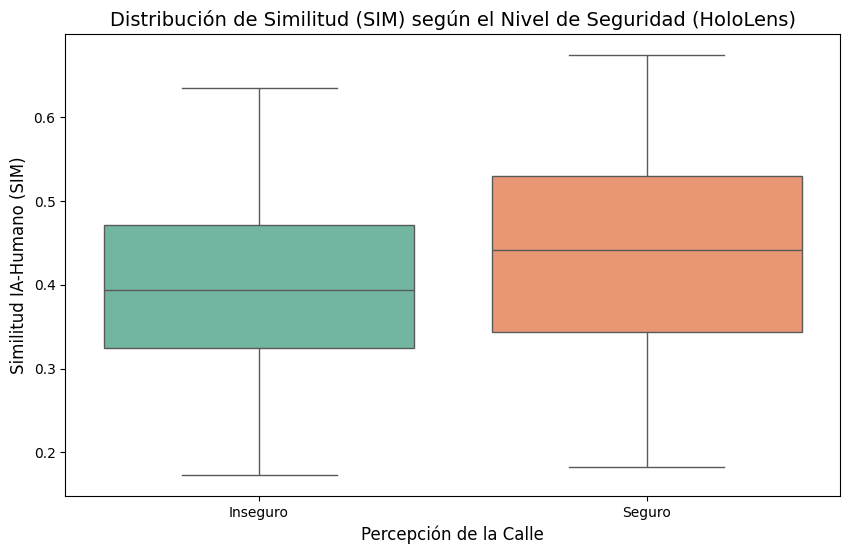

In [35]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar tus datos (los promedios de las 150 imágenes)
df = pd.read_csv('resultados_completos_xai_vs_humanos.csv')

# 2. Binarizar los scores (1 a 5 = Inseguro | 6 a 10 = Seguro)
# Asumimos que la escala llega hasta 10. Ajustamos el umbral a >= 6
df['Clase_HoloLens'] = np.where(df['Score_HoloLens'] >= 6.0, 'Seguro', 'Inseguro')
df['Clase_PP2'] = np.where(df['Score_PlacePulse2'] >= 6.0, 'Seguro', 'Inseguro')

# 3. Función para hacer la Prueba U de Mann-Whitney
def comparar_grupos(dataframe, columna_clase, metrica):
    grupo_seguro = dataframe[dataframe[columna_clase] == 'Seguro'][metrica].dropna()
    grupo_inseguro = dataframe[dataframe[columna_clase] == 'Inseguro'][metrica].dropna()
    
    # Solo hacer la prueba si ambos grupos tienen datos
    if len(grupo_seguro) > 0 and len(grupo_inseguro) > 0:
        stat, p_value = stats.mannwhitneyu(grupo_seguro, grupo_inseguro, alternative='two-sided')
        
        print(f"--- Métrica: {metrica} vs {columna_clase} ---")
        print(f"Promedio en Seguras:   {grupo_seguro.mean():.4f} (n={len(grupo_seguro)})")
        print(f"Promedio en Inseguras: {grupo_inseguro.mean():.4f} (n={len(grupo_inseguro)})")
        print(f"Valor-p (P-value):     {p_value:.4f}")
        
        if p_value < 0.05:
            print(" HALLAZGO: ¡Sí hay diferencia significativa! La IA se alinea distinto dependiendo del peligro.\n")
        else:
            print("No hay diferencia significativa entre calles seguras e inseguras.\n")

# 4. Ejecutar las pruebas
print("================ ANALIZANDO HOLOLENS (RÍO) ================")
comparar_grupos(df, 'Clase_HoloLens', 'SIM')
comparar_grupos(df, 'Clase_HoloLens', 'IoU')
comparar_grupos(df, 'Clase_HoloLens', 'NSS')

print("================ ANALIZANDO PLACE PULSE 2 (GLOBAL) ================")
comparar_grupos(df, 'Clase_PP2', 'SIM')
comparar_grupos(df, 'Clase_PP2', 'IoU')
comparar_grupos(df, 'Clase_PP2', 'NSS')

# 5. BONUS PARA TU PAPER: Un gráfico de cajas (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Clase_HoloLens', y='SIM', data=df, palette='Set2')
plt.title('Distribución de Similitud (SIM) según el Nivel de Seguridad (HoloLens)', fontsize=14)
plt.xlabel('Percepción de la Calle', fontsize=12)
plt.ylabel('Similitud IA-Humano (SIM)', fontsize=12)
plt.savefig('boxplot_sim_hololens.png', dpi=300)
plt.show()

In [ ]:
!pip install statsmodels

In [36]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. Cargar los datos
df = pd.read_csv('resultados_completos_xai_vs_humanos.csv')

# 2. Binarizar a 0 y 1 (Requisito estricto de la Regresión Logística)
# 1 = Seguro (>= 6) | 0 = Inseguro (< 6)
df['HoloLens_Binario'] = np.where(df['Score_HoloLens'] >= 6.0, 1, 0)
df['PP2_Binario'] = np.where(df['Score_PlacePulse2'] >= 6.0, 1, 0)

print(f"Distribución HoloLens: {df['HoloLens_Binario'].value_counts().to_dict()} (1=Seguro, 0=Inseguro)")

# 3. Función para ejecutar la Regresión Logística
def correr_regresion_logistica(datos, variable_dependiente):
    print(f"\n================ REGRESIÓN LOGÍSTICA: Prediciendo {variable_dependiente} ================")
    
    # Fórmula: Variable_Binaria explicada por SIM + IoU + NSS
    formula = f"{variable_dependiente} ~ SIM + IoU + NSS"
    
    try:
        # Ajustar el modelo Logit
        modelo = smf.logit(formula, data=datos)
        resultado = modelo.fit(disp=False) # disp=False oculta los mensajes de iteración
        
        # Imprimir el resumen estadístico clásico
        print(resultado.summary())
        
        # 4. CALCULAR LOS ODDS RATIOS (Lo más importante para tu tesis)
        print("\n--- INTERPRETACIÓN: ODDS RATIOS (Razón de Probabilidades) ---")
        odds_ratios = pd.DataFrame({
            "Odds Ratio": np.exp(resultado.params),
            "P-valor": resultado.pvalues
        })
        
        # Mostrar solo las variables, ignorando el "Intercept"
        for indice, fila in odds_ratios.drop('Intercept').iterrows():
            or_val = fila['Odds Ratio']
            p_val = fila['P-valor']
            
            significancia = "SIGNIFICATIVO" if p_val < 0.05 else "No significativo"
            
            # Formatear la interpretación en lenguaje humano
            if or_val > 1:
                porcentaje = (or_val - 1) * 100
                print(f"➤ {indice}: OR={or_val:.2f} (p={p_val:.3f}) [{significancia}]")
                print(f"   Por cada unidad que aumenta {indice}, la probabilidad de que la calle sea 'Segura' AUMENTA un {porcentaje:.1f}%.")
            else:
                porcentaje = (1 - or_val) * 100
                print(f"➤ {indice}: OR={or_val:.2f} (p={p_val:.3f}) [{significancia}]")
                print(f"   Por cada unidad que aumenta {indice}, la probabilidad de que la calle sea 'Segura' DISMINUYE un {porcentaje:.1f}%. (Es decir, predice peligro).")
                
    except Exception as e:
        print(f"Error al correr el modelo: {e}")

# 5. Ejecutar los modelos
correr_regresion_logistica(df, 'HoloLens_Binario')
correr_regresion_logistica(df, 'PP2_Binario')

Distribución HoloLens: {0: 109, 1: 41} (1=Seguro, 0=Inseguro)

================ REGRESIÓN LOGÍSTICA: Prediciendo HoloLens_Binario ================
                           Logit Regression Results                           
Dep. Variable:       HoloLens_Binario   No. Observations:                  150
Model:                          Logit   Df Residuals:                      146
Method:                           MLE   Df Model:                            3
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.03109
Time:                        19:22:58   Log-Likelihood:                -85.247
converged:                       True   LL-Null:                       -87.982
Covariance Type:            nonrobust   LLR p-value:                    0.1404
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6543      1.295     -1.277      0.201      -4.